In [55]:
from langgraph.graph import StateGraph, START, END

from typing import TypedDict

In [56]:
from typing import TypedDict

class AgenticState(TypedDict):

    number1: int
    number2: int 
    operation : str
    final_result : int


def add_numbers(state: AgenticState) -> AgenticState:

    state['final_result'] = state['number1'] + state['number2']

    return state


def sub_numbers(state: AgenticState) -> AgenticState:

    state['final_result'] = state['number1'] - state['number2']

    return state


def decide_next_node(state: AgenticState) -> str:

    if state['operation'] == "+":
        return  "addition_operation"

    elif state["operation"] == "-":
        return "subtraction_operation"

In [57]:
graph = StateGraph(AgenticState)

## router node

- It acts like a traffic cop standing at an intersection: the cop doesn't change the cars driving by (the state), they just point them in the correct direction (the conditional edge).

#### Why do this? (The Purpose of the "Router" Node)
You might wonder: "Why have a node that does absolutely nothing to the data?"

In LangGraph, you often need to make a decision about where to go next (using add_conditional_edges). However, conditional edges must be attached to a specific node.

By creating this "router" node with lambda state: state, you are creating a "dummy" or "structural" node.

- The graph arrives at "router".
- The "router" node does nothing to alter the data; it just passes the state along.
- Immediately after, your add_conditional_edges kicks in, looks at the untouched state, and decides whether to route to the "addition_operation" or "subtraction_operation".

In [ ]:

graph.add_node("add_node", add_numbers)
graph.add_node("subtract_node",sub_numbers)
graph.add_node("router", lambda state:state)           #passthrough funtion , as this funtion does not update the state and returning nothing so thats way 


#normal router funtion would be 
'''
def pass_through(state):
    return state

graph.add_node("router", pass_through)

'''

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",                                      # 1. THE SOURCE NODE
    decide_next_node,                              # 2. THE ROUTING FUNCTION
    {
        #edge nodes
        "addition_operation": "add_node",          # # 3. THE PATH MAP
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

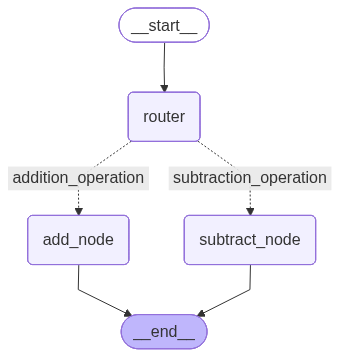

In [59]:
app

In [60]:
result = AgenticState(number1=2, number2=1, operation="+")

print(app.invoke(result))

{'number1': 2, 'number2': 1, 'operation': '+', 'final_result': 3}


## Exercise for Graph IV

- MAKE USE OF TWO CONDITIONAL EDGES

In [61]:
class AgenticState(TypedDict):

    number1 : int
    number2 : int
    number3 : int
    number4 : int
    
    operation1 : str
    operation2 : str

    final_Number1: int    
    final_Number2: int  



def add_numbers(state: AgenticState) -> AgenticState:

    state['final_Number1'] = state['number1'] + state['number2']

    return state


def sub_numbers(state: AgenticState) -> AgenticState:

    state['final_Number1'] = state['number3'] - state['number4']

    return state


def add_numbers_2(state: AgenticState) -> AgenticState:

    state['final_Number2'] = state['number3'] + state['number4']

    return state


def sub_numbers_2(state: AgenticState) -> AgenticState:

    state['final_Number2'] = state['number3'] - state['number4']

    return state


def decide_next_node(state: AgenticState) -> str:

    if state['operation1'] == "+":
        return  "addition_operation"

    elif state["operation1"] == "-":
        return "subtraction_operation"
        

def decide_next_node_2(state: AgenticState) -> str:

    if state['operation2'] == "+":
        return  "addition_operation"

    elif state["operation2"] == "-":
        return "subtraction_operation"



In [62]:
graph = StateGraph(AgenticState)

In [63]:

graph.add_node("add_node", add_numbers)
graph.add_node("sub_node", sub_numbers)
graph.add_node("add_node_2", add_numbers_2)
graph.add_node("sub_node_2", sub_numbers_2)
graph.add_node('router1', lambda state:state)
graph.add_node('router2', lambda state:state)

graph.add_edge(START, 'router1')

graph.add_conditional_edges(
    "router1",
    decide_next_node,
    {
        #edge nodes
        "addition_operation": "add_node",
        "subtraction_operation": "sub_node"
    }
    
    )
    

graph.add_conditional_edges(
    "router2",
    decide_next_node_2,
    {
        #edge nodes
        "addition_operation": "add_node_2",
        "subtraction_operation": "sub_node_2"
    }
    
    )


graph.add_edge('add_node', 'router2')
graph.add_edge('sub_node', 'router2')


graph.add_edge('sub_node_2', END)
graph.add_edge('add_node_2', END)


app = graph.compile()

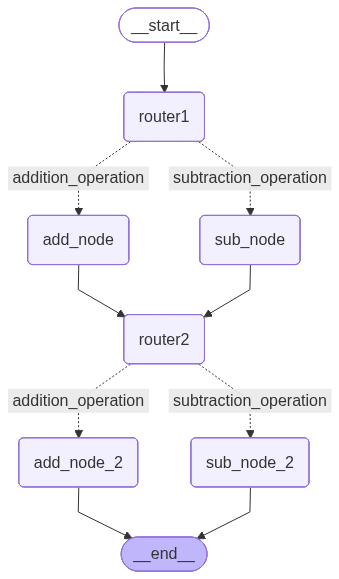

In [64]:

app

In [65]:
initial_state = AgenticState(number1=10, number2=20, number3=5, number4=10, operation1="+", operation2="-")
print(app.invoke(initial_state))

{'number1': 10, 'number2': 20, 'number3': 5, 'number4': 10, 'operation1': '+', 'operation2': '-', 'final_Number1': 30, 'final_Number2': -5}
